In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Setup done!")

Setup done!


In [2]:
import pandas as pd

df = pd.read_csv("cs-training.csv")
print("Shape:", df.shape)
print()
print("Columns:")
print(df.columns.tolist())
print()
df.head()

Shape: (150000, 12)

Columns:
['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']



,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
# 1. Unnamed column drop করি — এটা দরকার নেই
df = df.drop(columns=['Unnamed: 0'])

# 2. Target আর Feature আলাদা করি
y = df['SeriousDlqin2yrs']   # target (predict করতে চাই)
X = df.drop(columns=['SeriousDlqin2yrs'])   # features (input)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print()
print("Target distribution:")
print(y.value_counts())
print()
print("Target percentage:")
print(y.value_counts(normalize=True) * 100)

Features shape: (150000, 10)
Target shape: (150000,)

Target distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Target percentage:
SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


In [4]:
# Missing value count করি
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing:", df.isnull().sum().sum())

Missing values per column:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Total missing: 33655


In [5]:
# Median দিয়ে missing value fill করি
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

# Check করি এখন আর কোনো missing value আছে কিনা
print("After filling - Total missing:", df.isnull().sum().sum())

After filling - Total missing: 0


In [6]:
# X আর y আবার বানাই (updated df থেকে)
y = df['SeriousDlqin2yrs']
X = df.drop(columns=['SeriousDlqin2yrs'])

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Any missing in X?", X.isnull().sum().sum())
print("Any missing in y?", y.isnull().sum().sum())

X shape: (150000, 10)
y shape: (150000,)

Any missing in X? 0
Any missing in y? 0


In [7]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

print("After filling - Total missing:", df.isnull().sum().sum())

After filling - Total missing: 0


In [8]:
y = df['SeriousDlqin2yrs']
X = df.drop(columns=['SeriousDlqin2yrs'])

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Any missing in X?", X.isnull().sum().sum())
print("Any missing in y?", y.isnull().sum().sum())

X shape: (150000, 10)
y shape: (150000,)

Any missing in X? 0
Any missing in y? 0


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print()
print("Train target distribution:")
print(y_train.value_counts(normalize=True) * 100)
print()
print("Test target distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (120000, 10)
X_test shape: (30000, 10)
y_train shape: (120000,)
y_test shape: (30000,)

Train target distribution:
SeriousDlqin2yrs
0    93.315833
1     6.684167
Name: proportion, dtype: float64

Test target distribution:
SeriousDlqin2yrs
0    93.316667
1     6.683333
Name: proportion, dtype: float64


In [10]:
from sklearn.linear_model import LogisticRegression

# Model বানাই
model = LogisticRegression(max_iter=1000, random_state=42)

# Training data দিয়ে শেখাই
model.fit(X_train, y_train)

print("Model training complete!")
print()
print("Model type:", type(model).__name__)

Model training complete!

Model type: LogisticRegression


c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scaler শুধু training data দিয়ে fit করতে হয় (test data আগে model দেখেনি, তাই ওটা fit করব না)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaling complete!
X_train_scaled shape: (120000, 10)
X_test_scaled shape: (30000, 10)


In [12]:
# নতুন model বানাই
model = LogisticRegression(max_iter=1000, random_state=42)

# Scaled data দিয়ে train করি
model.fit(X_train_scaled, y_train)

print("Model training complete (with scaling)!")

Model training complete (with scaling)!


In [13]:
# Test data দিয়ে prediction করি
y_pred = model.predict(X_test_scaled)

# প্রতিটা prediction-এর probability-ও বের করি
# (class 1 মানে "default" হওয়ার probability)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Total predictions:", len(y_pred))
print()
print("First 20 predictions:", y_pred[:20])
print()
print("Predicted 0 count:", (y_pred == 0).sum())
print("Predicted 1 count:", (y_pred == 1).sum())

Total predictions: 30000

First 20 predictions: [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]

Predicted 0 count: 29845
Predicted 1 count: 155


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

# সব metric বের করি
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("===== MODEL PERFORMANCE =====")
print(f"Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print()
print("===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

===== MODEL PERFORMANCE =====
Accuracy : 0.9340  (93.40%)
Precision: 0.5806
Recall   : 0.0449
F1-Score : 0.0833
ROC-AUC  : 0.7143

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

  No Default       0.94      1.00      0.97     27995
     Default       0.58      0.04      0.08      2005

    accuracy                           0.93     30000
   macro avg       0.76      0.52      0.52     30000
weighted avg       0.91      0.93      0.91     30000



Confusion Matrix:
[[27930    65]
 [ 1915    90]]

True Negative  (আসলেই No Default, model বলেছে No Default): 27930
False Positive (আসলেই No Default, model বলেছে Default)   : 65
False Negative (আসলেই Default, model বলেছে No Default)   : 1915
True Positive  (আসলেই Default, model বলেছে Default)      : 90



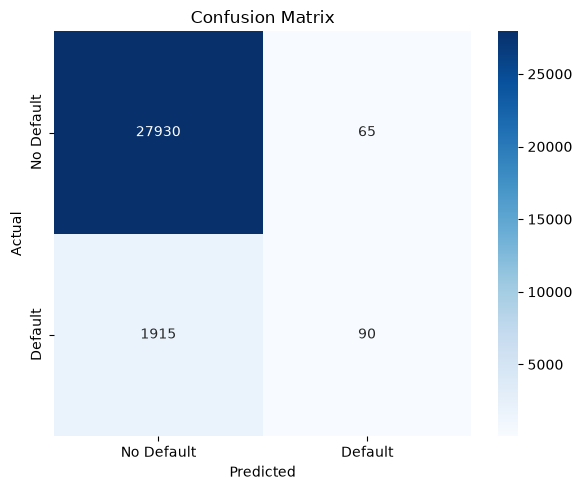

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print()
print(f"True Negative  (আসলেই No Default, model বলেছে No Default): {cm[0,0]}")
print(f"False Positive (আসলেই No Default, model বলেছে Default)   : {cm[0,1]}")
print(f"False Negative (আসলেই Default, model বলেছে No Default)   : {cm[1,0]}")
print(f"True Positive  (আসলেই Default, model বলেছে Default)      : {cm[1,1]}")
print()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest... (একটু সময় লাগবে)")
rf_model.fit(X_train_scaled, y_train)
print("Done!")

Training Random Forest... (একটু সময় লাগবে)
Done!


In [17]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Total predictions:", len(y_pred_rf))
print("Predicted 0 count:", (y_pred_rf == 0).sum())
print("Predicted 1 count:", (y_pred_rf == 1).sum())

Total predictions: 30000
Predicted 0 count: 25168
Predicted 1 count: 4832


In [18]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("===== RANDOM FOREST PERFORMANCE =====")
print(f"Accuracy : {accuracy_rf:.4f}  ({accuracy_rf*100:.2f}%)")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Default', 'Default']))

===== RANDOM FOREST PERFORMANCE =====
Accuracy : 0.8570  (85.70%)
Precision: 0.2635
Recall   : 0.6349
F1-Score : 0.3724
ROC-AUC  : 0.8557

              precision    recall  f1-score   support

  No Default       0.97      0.87      0.92     27995
     Default       0.26      0.63      0.37      2005

    accuracy                           0.86     30000
   macro avg       0.62      0.75      0.65     30000
weighted avg       0.92      0.86      0.88     30000



===== FEATURE IMPORTANCE (Random Forest) =====

RevolvingUtilizationOfUnsecuredLines          0.3178
NumberOfTimes90DaysLate                       0.1414
NumberOfTime30-59DaysPastDueNotWorse          0.1315
DebtRatio                                     0.0834
age                                           0.0824
NumberOfTime60-89DaysPastDueNotWorse          0.0726
MonthlyIncome                                 0.0701
NumberOfOpenCreditLinesAndLoans               0.0530
NumberRealEstateLoansOrLines                  0.0286
NumberOfDependents                            0.0193



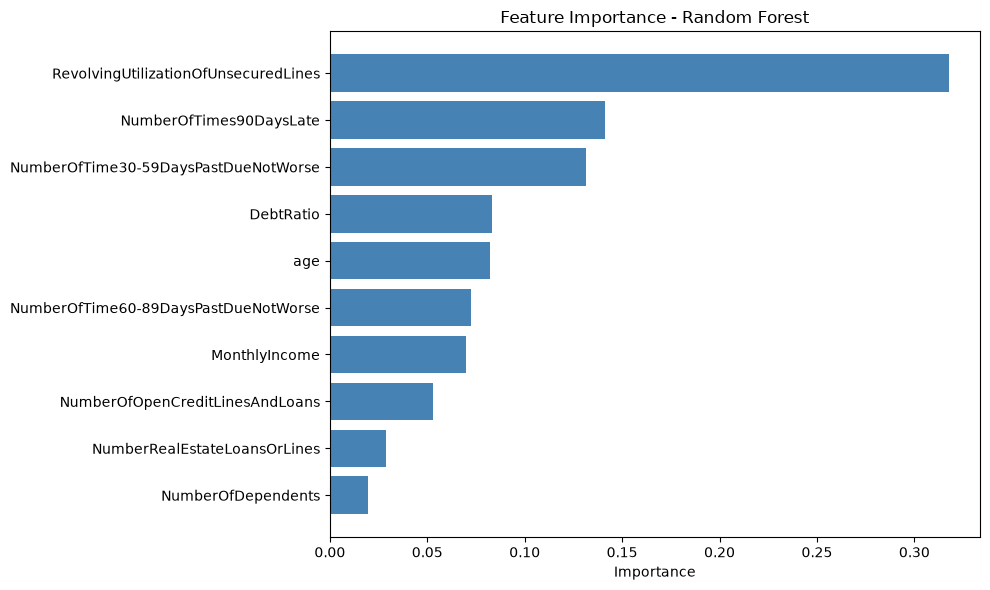

In [19]:
import matplotlib.pyplot as plt

# Feature importance বের করি
importances = rf_model.feature_importances_
feature_names = X.columns

# Sort করি (বড় থেকে ছোট)
indices = importances.argsort()[::-1]

print("===== FEATURE IMPORTANCE (Random Forest) =====")
print()
for i in indices:
    print(f"{feature_names[i]:<45} {importances[i]:.4f}")
print()

# Plot করি
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='steelblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
print("=" * 60)
print("  CREDIT SCORING MODEL - FINAL SUMMARY")
print("=" * 60)
print()
print(f"Dataset size: {len(df):,} samples, {X.shape[1]} features")
print(f"Target: SeriousDlqin2yrs (0 = No Default, 1 = Default)")
print(f"Class imbalance: {(y==0).sum()/len(y)*100:.2f}% No Default, {(y==1).sum()/len(y)*100:.2f}% Default")
print()
print("=" * 60)
print("  MODEL COMPARISON")
print("=" * 60)
print()
print(f"{'Metric':<20} {'Logistic Reg':<15} {'Random Forest':<15}")
print("-" * 50)
print(f"{'Accuracy':<20} {accuracy:.4f}          {accuracy_rf:.4f}")
print(f"{'Precision':<20} {precision:.4f}          {precision_rf:.4f}")
print(f"{'Recall':<20} {recall:.4f}          {recall_rf:.4f}")
print(f"{'F1-Score':<20} {f1:.4f}          {f1_rf:.4f}")
print(f"{'ROC-AUC':<20} {roc_auc:.4f}          {roc_auc_rf:.4f}")
print()
print("=" * 60)
print("  BEST MODEL: Random Forest")
print("=" * 60)
print(f"Winner because of {recall_rf/recall:.1f}x better Recall on Default class.")
print("In credit scoring, missing a defaulter (False Negative) is more")
print("costly than wrongly flagging a good customer (False Positive).")
print()
print("=" * 60)

  CREDIT SCORING MODEL - FINAL SUMMARY

Dataset size: 150,000 samples, 10 features
Target: SeriousDlqin2yrs (0 = No Default, 1 = Default)
Class imbalance: 93.32% No Default, 6.68% Default

  MODEL COMPARISON

Metric               Logistic Reg    Random Forest  
--------------------------------------------------
Accuracy             0.9340          0.8570
Precision            0.5806          0.2635
Recall               0.0449          0.6349
F1-Score             0.0833          0.3724
ROC-AUC              0.7143          0.8557

  BEST MODEL: Random Forest
Winner because of 14.1x better Recall on Default class.
In credit scoring, missing a defaulter (False Negative) is more
costly than wrongly flagging a good customer (False Positive).

